In [7]:
import pandas as pd
import glob
import os
import re
import sys
from omegaconf import OmegaConf

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

data = pd.read_pickle('../sampling_test/validated_final_df.pkl')
data = data[~data['Ucell'].isna()]
parameter_ranges = OmegaConf.load('../param_config.yaml')

### Fitting a Random Forest to predict the sum of the voltages

In [5]:
import time
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# === 0) Prepare data X, y ===
target_cols = [f"Ucell_{i}" for i in range(30)]
X = data[parameter_ranges].values
y = data[target_cols].sum(axis=1).values

# === 1) Scale once up front ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 2) Define outer/inner CV ===
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=1)

# === 3) RF + grid for inner tuning ===
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators':     [100, 200, 500],
    'max_depth':        [None, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

inner_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# === 4) Outer loop: tune & test ===
outer_mse = []
outer_r2  = []
best_params = []

start = time.time()
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_scaled, y), 1):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Inner CV for hyper‐tuning (maximizes mean R²)
    inner_search.fit(X_train, y_train)
    best_params.append(inner_search.best_params_)

    # Evaluate best model on outer test fold
    best_model = inner_search.best_estimator_
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    outer_mse.append(mse)
    outer_r2.append(r2)

    print(f"Fold {fold} → Best inner R²: {inner_search.best_score_:.4f}, "
          f"Test MSE: {mse:.4f}, Test R²: {r2:.4f}")

elapsed = time.time() - start
print(f"\nNested CV done in {elapsed:.1f}s")

# === 5) Summaries ===
print(f"\nAvg outer‐fold MSE: {np.mean(outer_mse):.4f} ± {np.std(outer_mse):.4f}")
print(f"Avg outer‐fold R²:  {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")

print("\nBest params per fold:")
for i, p in enumerate(best_params, 1):
    print(f" Fold {i}: {p}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fold 1 → Best inner R²: -658.3328, Test MSE: 374.6001, Test R²: 0.8100
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fold 2 → Best inner R²: -598.7165, Test MSE: 474.4192, Test R²: 0.7710
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fold 3 → Best inner R²: -592.3391, Test MSE: 481.0709, Test R²: 0.7148
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fold 4 → Best inner R²: -498.5557, Test MSE: 969.9704, Test R²: 0.6513
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fold 5 → Best inner R²: -541.9006, Test MSE: 507.9110, Test R²: 0.6999

Nested CV done in 771.9s

Avg outer‐fold MSE: 561.5943 ± 209.1427
Avg outer‐fold R²:  0.7294 ± 0.0555

Best params per fold:
 Fold 1: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}
 Fold 2: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}
 Fold 3: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}
 Fold 4: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}
 Fold 5: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

target_cols = [f"Ucell_{i}" for i in range(30)]
X = data[parameter_ranges].values
y = data[target_cols].sum(axis=1).values

# 1) Build the pipeline with scaling inside each fold
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
])

# 2) Define the same shuffled KFold you used in nested CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) Run cross_val_score with R² scoring
scores = cross_val_score(
    pipe,
    X,              # your original feature matrix (unscaled)
    y,              # your summed-Ucell target
    cv=cv,
    scoring="r2",
    n_jobs=-1,
)

print(f"5-fold CV R² (shuffled): {scores.mean():.4f} ± {scores.std():.4f}")


5-fold CV R² (shuffled): 0.7291 ± 0.0557


Get the Feature Importance of the Random Forest with shap

        feature  importance
0           tau    9.368148
1    epsilon_mc    8.033226
2           Tfc    2.236985
3      i0_c_ref    1.693516
4        Pa_des    1.327418
5     Phi_c_des    1.077331
6            Re    0.900621
7       kappa_c    0.770872
8            Sc    0.673007
9     epsilon_c    0.632126
10  epsilon_gdl    0.530479
11     kappa_co    0.502837
12            e    0.128237


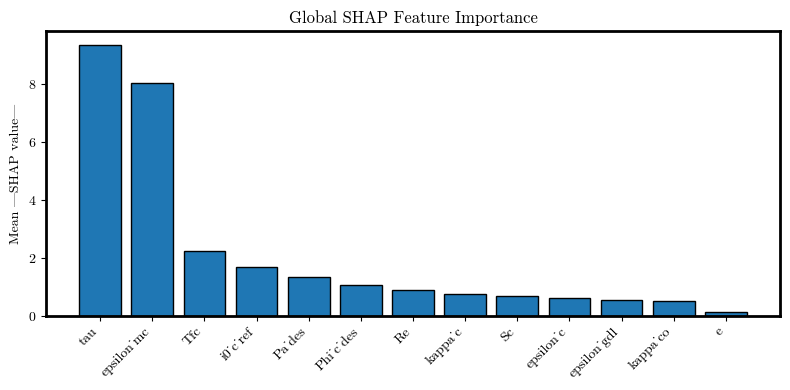

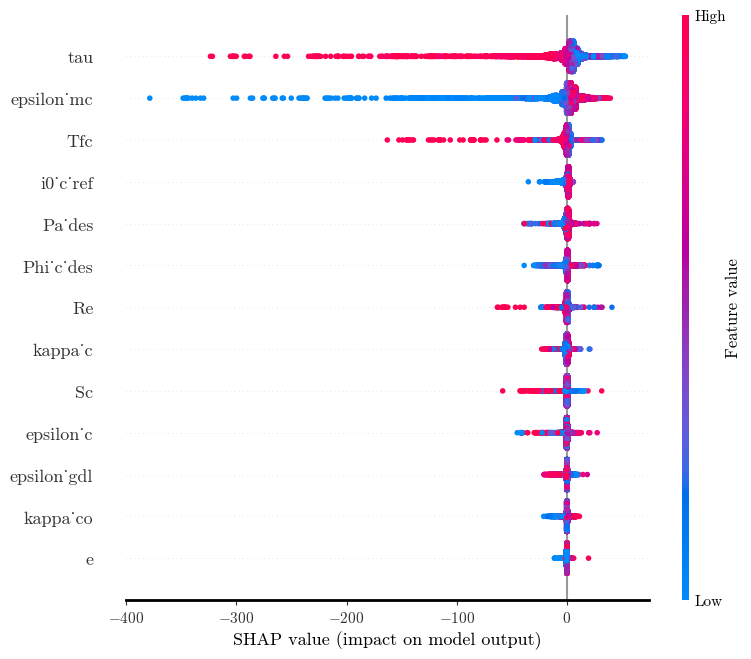

<Figure size 640x480 with 0 Axes>

In [10]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

features = list(parameter_ranges)
rf_model  = pipe.named_steps["rf"]
scaler    = pipe.named_steps["scaler"]

# Scale your data once:
X_scaled  = scaler.transform(X)

# --- 1) Build a TreeExplainer on the RF alone ---
explainer = shap.TreeExplainer(rf_model)

# --- 2) Compute SHAP values (exact, very fast) ---
# Returns an array of shape (n_samples, n_features)
shap_values = explainer.shap_values(X_scaled)

# --- 3) Compute global importances = mean(|SHAP|) per feature ---
importances = np.mean(np.abs(shap_values), axis=0)
df_imp = pd.DataFrame({
    "feature":    features,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# --- 4) Print the table ---
print(df_imp)

# --- 5) Bar plot of global SHAP importances ---
plt.figure(figsize=(8,4))
plt.bar(df_imp["feature"], df_imp["importance"], edgecolor='k')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean |SHAP value|")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

# --- 6) (Optional) Beeswarm plot for detailed distribution ---
plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_scaled, feature_names=features)
plt.tight_layout()
plt.show()


Create Ucell regions

In [11]:
# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer

df = data
df['Ucell'] = df[target_cols].apply(list, axis=1)
SA = SensitivityAnalyzer(parameter_ranges=parameter_ranges)
df['Ucell_regions'] = SA.aggregate_output_function(df, aggregation_method='sum', by_regions=True)


### Fit a RF for each region (regions aggregated using the sum) and calculate shap

Region 1: CV R² = 0.7016 ± 0.0528


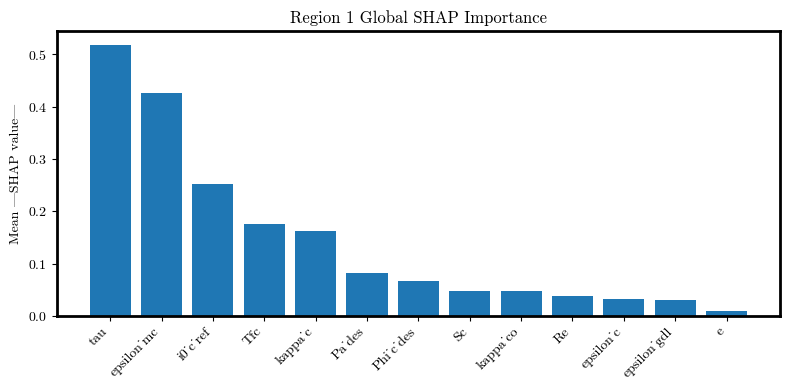

Region 2: CV R² = 0.7235 ± 0.0474


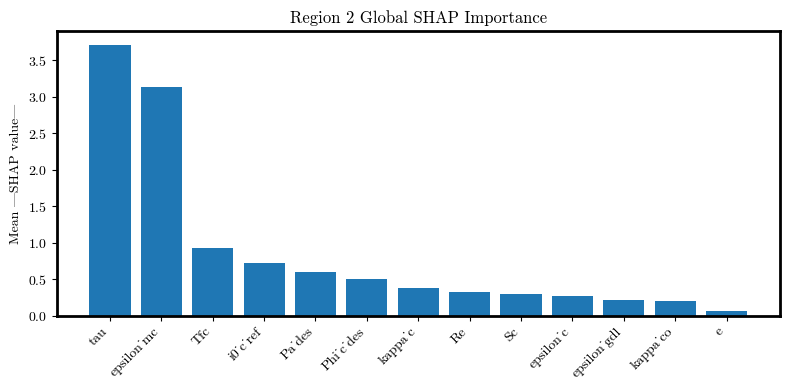

Region 3: CV R² = 0.7215 ± 0.0470


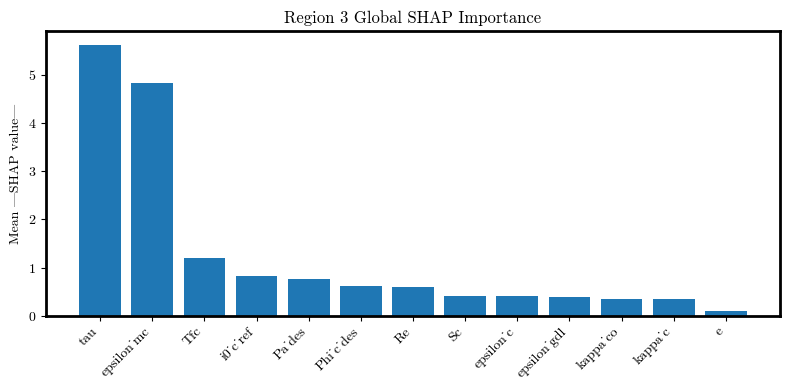

In [12]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Assumes df, parameter_ranges, and Y array are defined as:
X = df[parameter_ranges].values   # shape (n_samples, n_features)
Y = np.stack(df['Ucell_regions']) # shape (n_samples, 3)

# Configuration
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
shap_importances = {region: [] for region in range(3)}  # store per-fold importances
region_r2 = {region: [] for region in range(3)}

# Perform CV
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    # Split
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Loop over regions
    for region in range(3):
        # Train RF
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train_scaled, Y_train[:, region])
        
        # Evaluate R2
        y_pred = rf.predict(X_test_scaled)
        region_r2[region].append(r2_score(Y_test[:, region], y_pred))
        
        # Compute SHAP on test fold
        explainer = shap.TreeExplainer(rf)
        shap_vals = explainer.shap_values(X_test_scaled)
        mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
        shap_importances[region].append(mean_abs_shap)
        
# Aggregate and plot
for region in range(3):
    # Average importances over folds
    imp_array = np.vstack(shap_importances[region])
    avg_imp = np.mean(imp_array, axis=0)
    df_imp = pd.DataFrame({
        'feature': parameter_ranges,
        'mean_abs_shap': avg_imp
    }).sort_values('mean_abs_shap', ascending=False)
    
    # Print performance
    mean_r2 = np.mean(region_r2[region])
    std_r2  = np.std(region_r2[region])
    print(f"Region {region+1}: CV R² = {mean_r2:.4f} ± {std_r2:.4f}")
    
    # Plot bar chart
    plt.figure(figsize=(8, 4))
    plt.bar(df_imp['feature'], df_imp['mean_abs_shap'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Mean |SHAP value|')
    plt.title(f'Region {region+1} Global SHAP Importance')
    plt.tight_layout()
    plt.show()
